## Calculate Climatologies

calc climatology of true melt, and melt predicted by ModularNN (modularNN trial_21)

In [1]:
import os

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import xarray as xr

In [2]:
base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'evaluations')[0]
data_dir = os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5'])

# Calculate Climatologies of true and predicted snmelt data

In [3]:
def calc_smoothed_climatology(_ds, rolling_window=15, time_dim='time'):
    """
    Calculate smoothed climatology using a rolling mean with specified window size.
    """
    
    window_size = 15
    
    if time_dim == 'month_day':
        month_day = _ds.month_day.values
        time_index = pd.to_datetime('1980-' + month_day + ' 12:00', format='%Y-%m-%d %H:%M', errors='coerce')
        _ds = _ds.assign_coords(time=('month_day', time_index)).swap_dims({'month_day': 'time'})

    # add padding at beginning and end to avoid edge effects
    time = _ds['time'].values
    dt = time[1] - time[0]
    period = time[-1] - time[0] + dt
    padding_size = window_size // 2
    left_slice = slice(-padding_size, None)
    right_slice = slice(0, padding_size)
    left = _ds.isel({'time': left_slice}).copy()
    right = _ds.isel({'time': right_slice}).copy()
    left_time = left['time'].values - period
    right_time = right['time'].values + period
    left = left.assign_coords({'time': left_time})
    right = right.assign_coords({'time': right_time})

    ds_padded = xr.concat([left, _ds, right], dim='time')

    ds_clim_15 = ds_padded.rolling(time=rolling_window, center=True, min_periods=rolling_window).mean()
    ds_clim_15 = ds_clim_15.sel(time=time) # remove padding

    # set all years to a common leap year (e.g., 1980) to have valid datetime index
    ti = pd.to_datetime(ds_clim_15['time'].values) 
    new_ti = ti.map(lambda t: t.replace(year=1980)) 
    ds_clim_15 = ds_clim_15.assign_coords(time=('time', new_ti))


    return   ds_clim_15


# calculated daily climatology
def calc_daily_climatology(_da):
    md = _da.time.dt.strftime('%m-%d')
    md.name = 'month_day' 

    climatology = _da.groupby(md).mean(dim='time')

    if 'z' in climatology.dims:
        clim_unstacked = climatology.set_index(z=['y', 'x']).unstack('z')
        return clim_unstacked
    else:
        return climatology


# # compute snmel climatology smoothed with a 15-day rolling mean
# # daily climatologies were calculated with 'cdo ydaymean -mergetime Daily2D_GRL_{1990..2013}.nc climat_1990-2013.nc'
# ds_clim_daily = xr.load_dataset(os.path.sep.join([data_dir_loc, 'climat_snmel_1990-2013.nc']))
# ds_clim_15 = calc_smoothed_climatology(ds_clim_daily, rolling_window=15)
# ds_clim_15.to_netcdf(os.path.sep.join([data_dir, 'climat_snmel_1990-2013_smoothed15.nc']))


# # load prediction file
# pred_dir = os.path.sep.join([base_dir, 'output', 'modularNN'])
# ds = xr.open_dataset(os.path.sep.join([pred_dir, 'pred_data_1990-2016.zarr']))
# time_indices = slice('1990-01-01','2013-12-31')    # get period to calculate climatology from
# melt_train = ds.sel(time=time_indices)['snmel_pred']

# print('Calculating daily climatology...')
# clim_daily = calc_daily_climatology(melt_train)
# print('Smoothing daily climatology...')
# snmel_clim_pred = calc_smoothed_climatology(clim_daily, rolling_window=15, time_dim='month_day')

# # save smoothed climatology
# pred_clim_file = os.path.sep.join([pred_dir, 'pred_climat_1990-2013_15dayrolling.zarr'])
# snmel_clim_pred.to_zarr(pred_clim_file, mode='w')    # overwrite/create

/tmp/squashed-elkesc-store/store/miniforge3/envs/env_FirnML/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


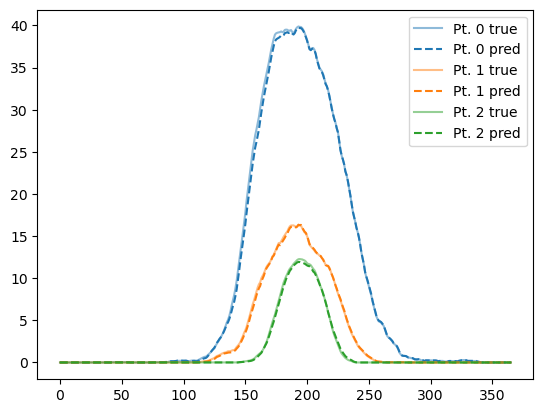

In [6]:
# plot true vs predicted climatology at selected points
ds_clim = xr.load_dataset(os.path.sep.join([data_dir, 'firnpack', 'climat_snmel_1990-2013_smoothed15.nc']))
snmel_clim = ds_clim['snmel']

pred_clim_file = os.path.sep.join([base_dir, 'output', 'modularNN', 'pred_climat_1990-2013_15dayrolling.zarr'])
snmel_clim_pred = xr.open_zarr(pred_clim_file)['snmel_pred']


cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = [mcolors.to_hex(c) for c in cmap.colors[:3]]

pts = [(100,240), (140, 170), (290, 430)]

plt.figure()

for i, pt in enumerate(pts):
    plt.plot(snmel_clim.sel(x=pt[0], y=pt[1]).values, label=f'Pt. {i} true', color=colors[i], alpha=0.5)
    plt.plot(snmel_clim_pred.sel(x=pt[0], y=pt[1]).values, label=f'Pt. {i} pred', color=colors[i], linestyle='--')

plt.legend()
plt.show()

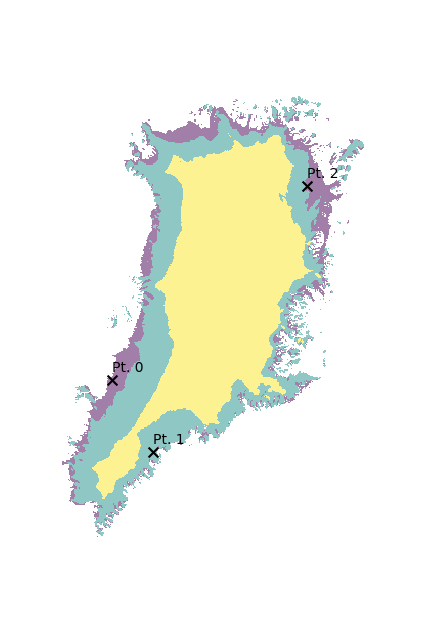

In [7]:
# plot location of points from above on zone map
ds_zones = xr.open_dataset(os.path.sep.join([data_dir, 'AuxFiles', 'GRLzones.nc']))
Z = ds_zones['zones']

fig, ax = plt.subplots(figsize=(8,8))
ax.pcolormesh(Z, alpha=0.5)
for i,pt in enumerate(pts): 
    plt.scatter(pt[0], pt[1], color='black', s=50, marker='x')
    ax.annotate(f'Pt. {i}', pt, textcoords="offset points", xytext=(0,6))

plt.axis('off')
plt.gca().set_aspect(1)
plt.show()